### Import Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
##202431129 Gian Ananda Virja

In [2]:
df = pd.read_csv('datasethealth.csv')
df.info()
df.head(10)
##202431129 Gian Ananda Virja

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


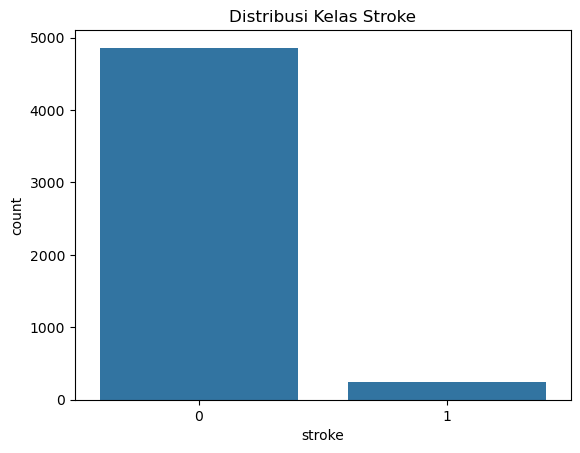

In [3]:
df.describe(include = "all")

sns.countplot(x = "stroke", data = df)
plt.title("Distribusi Kelas Stroke")
plt.show()
##202431129 Gian Ananda Virja

In [11]:
df.dtypes

id                     int64
gender                   str
age                  float64
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object

In [4]:
cat_col = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

for col in cat_col:
    df[col] = df[col].astype('category')

df.dtypes
##202431129 Gian Ananda Virja

id                      int64
gender               category
age                   float64
hypertension            int64
heart_disease           int64
ever_married         category
work_type            category
Residence_type       category
avg_glucose_level     float64
bmi                   float64
smoking_status       category
stroke                  int64
dtype: object

### Detection and Treatment of Missing Values

In [5]:
df.isnull().sum()
##202431129 Gian Ananda Virja

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [6]:
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

df.head()
##202431129 Gian Ananda Virja

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


<function matplotlib.pyplot.show(close=None, block=None)>

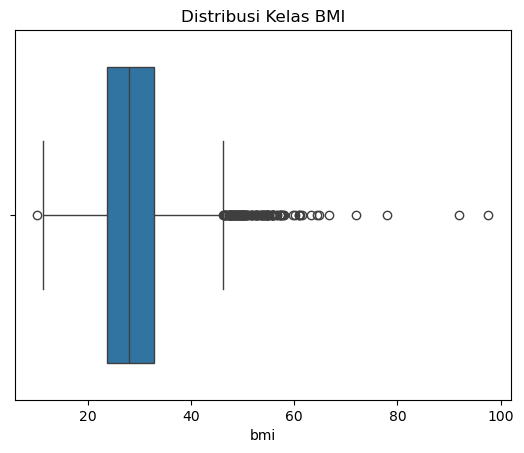

In [7]:
sns.boxplot(x="bmi", data = df)
plt.title("Distribusi Kelas BMI")
plt.show
##202431129 Gian Ananda Virja

In [8]:
Q1 = df['age'].quantile(1/4)
Q3 = df['age'].quantile(3/4)

IQR = Q3 - Q1

lower_bound = Q1 - 3/2 * IQR
upper_bound = Q3 + 3/2 * IQR
outliers = df[(df["age"] < lower_bound) | (df["age"] > upper_bound)]
print("Jumlah outliner umur: ", len(outliers))
##202431129 Gian Ananda Virja

Jumlah outliner umur:  0


### Corelation of variables

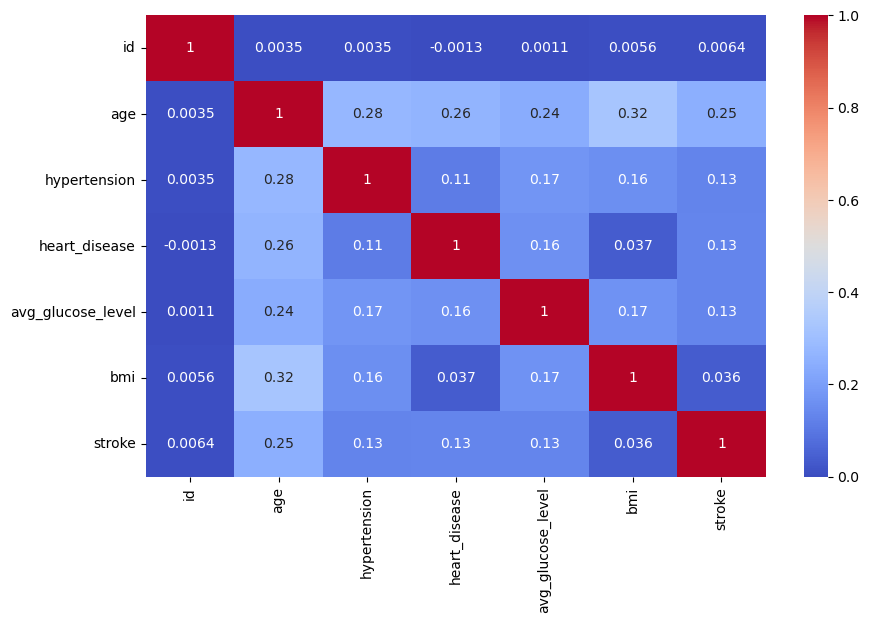

In [9]:
num_df = df.select_dtypes(include = ['int64', 'float64'])

plt.figure(figsize = (10,6))
sns.heatmap(num_df.corr(), annot = True, cmap = "coolwarm")
plt.show()
##202431129 Gian Ananda Virja

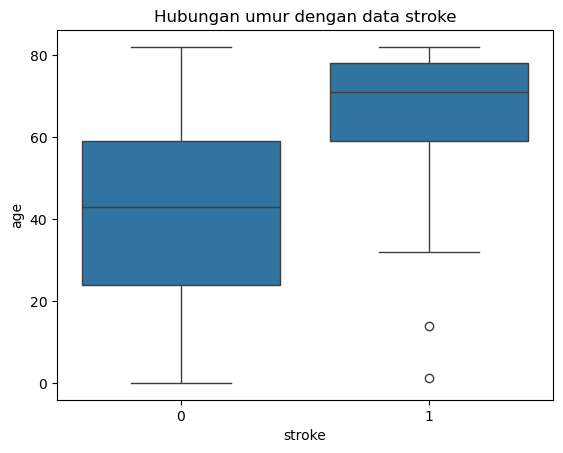

In [10]:
sns.boxplot(x = "stroke", y = "age", data = df)
plt.title("Hubungan umur dengan data stroke")
plt.show()
##202431129 Gian Ananda Virja